In [2]:
import json
import requests
import pandas as pd
import numpy as np

from datetime import datetime
from datetime import date, timedelta
from dateutil.relativedelta import relativedelta
from datetime import date
import math 

import matplotlib.pyplot as plt 
import matplotlib.ticker as ticker
from matplotlib.dates import DateFormatter

# import eurostat #python wrapper for taking data. 
import time

In [3]:
Share_point = r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Data\Storage'

In [4]:
import os
os.chdir(Share_point)

In [5]:
EU27 = pd.read_excel('eu27.xlsx')
Europe = pd.read_excel('MS + EU.xlsx', sheet_name='Europe') 

In [6]:
twodigit = Europe['API']  # FOR THE EU IT MUST BE TYPE=EU NOT COUNTRY=EU
# twodigit = EU27['twodigit']

In [7]:
import os
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - 2021-11 European natural gas imports\\Data\\Storage'

In [8]:
# headers = {"x-key":"c004438249338e49ed35e0ffce94cb6a"}
# print(headers)

In [9]:
from datetime import date
today = date.today()
print(today)

2023-04-04


## May need updating (every 6 months)

In [10]:
# headers = {"x-key":"c004438249338e49ed35e0ffce94cb6a"}
headers = {"x-key":"d8561648296cb38e6c400823755689941530"} # After July 4th

In [11]:
dates = []
values = []
percentages = []
status = []
max_storage = []
country = []

for idt in twodigit:
    try:
#        url = 'https://agsi.gie.eu/api/data/{}'.format(idt)      #changed on 5 April 2022
        url = 'https://agsi.gie.eu/api?{}&from=2023-01-01&to={}&size=300'.format(idt,str(today))
#         url = 'https://agsi.gie.eu/api?{}&from=2022-07-01&to=2022-12-31&size=300'.format(idt)  
        r = requests.get(url,headers=headers)
        data = r.json()
        inner_data = data['data']
        for x in inner_data:
                #here we work with the APIs
#                 date = x['gasDayStartedOn']     # Changed on 5 April 2022
                date = x['gasDayStart']
                value = x['gasInStorage']
                percentage = x['full']
                statuses = x['status']
                Max_Storage = x['workingGasVolume']
                countries = x['code']


                dates.append(date)     
                values.append(value)
                percentages.append(percentage)
                status.append(statuses)
                max_storage.append(Max_Storage)
                country.append(countries)
    except Exception as e:
        print(e)
        print(idt)

'gasInStorage'
country=CY
'gasInStorage'
country=EE
'gasInStorage'
country=FI
'gasInStorage'
country=GR
'gasInStorage'
country=LT
'gasInStorage'
country=LU
'gasInStorage'
country=MT
'gasInStorage'
country=SI


In [12]:
df = pd.DataFrame()
df['dates'] = dates
df['values'] = values
df['% full'] = percentages
df['status'] = status
df['Max Storage'] = max_storage
df['country'] = country

In [13]:
df[df['country']=='eu'].head()

,dates,values,% full,status,Max Storage,country
2024,2023-04-02,626.9805,55.71,E,1125.5283,eu
2025,2023-04-01,625.0651,55.53,E,1125.6847,eu
2026,2023-03-31,625.5199,55.65,E,1124.0174,eu
2027,2023-03-30,625.1483,55.64,E,1123.6367,eu
2028,2023-03-29,624.7104,55.6,E,1123.6367,eu


In [14]:
# df = df.set_index(pd.DatetimeIndex(df['dates']))

In [15]:
# Getting rid of NaN
df.replace('', np.NaN)
# Getting rid of observations for which we have no data
df = df[df['status']!='N']

In [16]:
df['values'] = pd.to_numeric(df['values']) 
df['% full'] = pd.to_numeric(df['% full'])
df['Max Storage'] = pd.to_numeric(df['Max Storage']) 

save data

In [17]:
# Change current directory
import os
os.chdir(Share_point + '\Storage by country\historic data (10.05.2022)')

In [18]:
df.to_csv(r'Storage_2023_1.csv')

### Merge historic and 2022 data

In [19]:
df_1a = pd.read_csv('Storage_2015_1.csv',index_col=0)
df_1b = pd.read_csv('Storage_2015_2.csv',index_col=0)
df_2a = pd.read_csv('Storage_2016_1.csv',index_col=0)
df_2b = pd.read_csv('Storage_2016_2.csv',index_col=0)
df_3a = pd.read_csv('Storage_2017_1.csv',index_col=0)
df_3b = pd.read_csv('Storage_2017_2.csv',index_col=0)
df_4a = pd.read_csv('Storage_2018_1.csv',index_col=0)
df_4b = pd.read_csv('Storage_2018_2.csv',index_col=0)
df_5a = pd.read_csv('Storage_2019_1.csv',index_col=0)
df_5b = pd.read_csv('Storage_2019_2.csv',index_col=0)
df_6a = pd.read_csv('Storage_2020_1.csv',index_col=0)
df_6b = pd.read_csv('Storage_2020_2.csv',index_col=0)
df_7a = pd.read_csv('Storage_2021_1.csv',index_col=0)
df_7b = pd.read_csv('Storage_2021_2.csv',index_col=0)
df_8a = pd.read_csv('Storage_2022_1.csv',index_col=0)
df_8b = pd.read_csv('Storage_2022_2.csv',index_col=0)
df_9a = pd.read_csv('Storage_2023_1.csv',index_col=0)

In [20]:
df = pd.concat([df_1a,df_1b,df_2a,df_2b,df_3a,df_3b,df_4a,df_4b,df_5a,df_5b,df_6a,df_6b,df_7a,df_7b,df_8a,df_8b,df_9a])

In [21]:
from datetime import date
# storage data by country in TWh
df.to_csv(Share_point + '\Storage by country\Storage by country {}.csv'.format(date.today()))

In [22]:
## Get rid of the following when the APIs work again

In [23]:
dff = df.groupby(['country','dates'])['values'].mean().reset_index()

#### Eu stuff

In [24]:
EUdff = df.groupby(['country','dates'])['values'].sum().reset_index()
EUdff = EUdff.set_index(pd.DatetimeIndex(EUdff['dates']))
EUdff.tail(3)

,country,dates,values
dates,,,
2023-03-31,eu,2023-03-31,625.5199
2023-04-01,eu,2023-04-01,625.0651
2023-04-02,eu,2023-04-02,626.9805


In [25]:
del EUdff['dates']

In [26]:
# Weekly data for the EU in M3m
converter=0.0103
euplot_days = EUdff[EUdff['country']== 'eu'].groupby(pd.Grouper(freq='W')).mean()/converter
# euplot_days.to_csv(Share_point + '\EU weekly\EU storage data {}.csv'.format(date.today()))

C:\Users\giovanni.sgaravatti\AppData\Local\Temp\ipykernel_2840\3684749521.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  euplot_days = EUdff[EUdff['country']== 'eu'].groupby(pd.Grouper(freq='W')).mean()/converter


In [27]:
EUdff.index.year.unique()

Int64Index([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023], dtype='int64', name='dates')

In [28]:
EU= EUdff[EUdff['country']== 'eu']

In [29]:
EU.head()

,country,values
dates,,
2015-01-01,eu,748.3692
2015-01-02,eu,743.4778
2015-01-03,eu,739.2633
2015-01-04,eu,735.0244
2015-01-05,eu,729.0182


In [30]:
min_per_y = EU.groupby(EU.index.year)['values'].min()

In [31]:
for i in min_per_y:
    print(EU[EU['values']==i].index)

DatetimeIndex(['2015-04-09'], dtype='datetime64[ns]', name='dates', freq=None)
DatetimeIndex(['2016-03-30'], dtype='datetime64[ns]', name='dates', freq=None)
DatetimeIndex(['2017-03-31'], dtype='datetime64[ns]', name='dates', freq=None)
DatetimeIndex(['2018-03-31'], dtype='datetime64[ns]', name='dates', freq=None)
DatetimeIndex(['2019-03-31'], dtype='datetime64[ns]', name='dates', freq=None)
DatetimeIndex(['2020-03-31'], dtype='datetime64[ns]', name='dates', freq=None)
DatetimeIndex(['2021-04-20'], dtype='datetime64[ns]', name='dates', freq=None)
DatetimeIndex(['2022-03-19'], dtype='datetime64[ns]', name='dates', freq=None)
DatetimeIndex(['2023-03-21'], dtype='datetime64[ns]', name='dates', freq=None)


### Storage by country for Flourish

In [32]:
from datetime import date
today=date.today()

In [33]:
today

datetime.date(2023, 4, 4)

In [34]:
last_obs = today - timedelta(days=2)
print(last_obs)

2023-04-02


In [35]:
last_month = last_obs - timedelta(days=30)
print(last_month)

2023-03-03


In [36]:
df_Florish = df[['dates','values','% full','Max Storage','country']]

In [37]:
df_Florish = df_Florish.set_index(pd.DatetimeIndex(df['dates']))

In [38]:
del df_Florish['dates']

In [39]:
df_Florish = df_Florish[df_Florish.index.isin([str(last_obs),str(last_month)])]

In [40]:
countries = df_Florish['country'].unique()

In [54]:
Date =[]
This_month_filling = []
State = []
Max_storage = []
values = []
Percent = []
Eighty_percent = []
Last_month = []
Forty_p = []
Twenty_p = []

for country in countries:
    df_Florish_new = df_Florish[df_Florish['country']== country] 
    latest_value = df_Florish_new.loc[str(last_obs),'values']#[0]
    perc = df_Florish_new.loc[str(last_obs),'% full']#[0]
    Prev_value = df_Florish_new.loc[str(last_month),'values']#[0]
    TWh = latest_value - Prev_value
        
    Capacity = df_Florish_new.iloc[0,2]
    Target = Capacity * 0.8
    Twenty = Capacity * 0.2
    Forty = Capacity * 0.4
    
    Date.append(last_obs)
    Percent.append(perc)
    Last_month.append(Prev_value)
    This_month_filling.append(TWh)
    values.append(latest_value) 
    State.append(country)
    Max_storage.append(Capacity)
    Eighty_percent.append(Target)
    Forty_p.append(Forty)
    Twenty_p.append(Twenty)

In [55]:
df_stack_bar = pd.DataFrame()
df_stack_bar['date']= Date
df_stack_bar['country'] = State
df_stack_bar['% full'] = Percent
df_stack_bar['latest values'] = values
df_stack_bar['30 days ago value'] = Last_month
df_stack_bar['Last 30 days change'] = This_month_filling
df_stack_bar['Max capacity'] = Max_storage
df_stack_bar['80 % target'] = Eighty_percent
df_stack_bar['40 %'] = Forty_p
df_stack_bar['20 %'] = Twenty_p

In [56]:
df_stack_bar

,date,country,% full,latest values,30 days ago value,Last 30 days change,Max capacity,80 % target,40 %,20 %
0,2023-04-02,AT,64.60,62.6212,66.3489,-3.7277,96.9420,77.55360,38.77680,19.38840
1,2023-04-02,BE,35.71,2.7172,3.3687,-0.6515,7.6100,6.08800,3.04400,1.52200
2,2023-04-02,BG,77.54,4.4993,4.4993,0.0000,5.8025,4.64200,2.32100,1.16050
3,2023-04-02,HR,75.74,3.6145,3.6945,-0.0800,4.7725,3.81800,1.90900,0.95450
4,2023-04-02,CZ,55.95,24.7255,27.0269,-2.3014,44.1907,35.35256,17.67628,8.83814
5,2023-04-02,DK,71.54,7.0429,7.5424,-0.4995,9.8450,7.87600,3.93800,1.96900
6,2023-04-02,FR,28.09,37.5303,51.9700,-14.4397,133.6026,106.88208,53.44104,26.72052
7,2023-04-02,DE,64.39,160.9035,169.5792,-8.6757,249.8915,199.91320,99.95660,49.97830
8,2023-04-02,HU,44.94,30.4261,32.1985,-1.7724,67.7027,54.16216,27.08108,13.54054
9,2023-04-02,IT,59.21,114.5320,114.1448,0.3872,193.4434,154.75472,77.37736,38.68868


In [57]:
df_stack_bar['values root'] = df_stack_bar['latest values']**(1/2)

In [58]:
df_stack_bar['country'] = df_stack_bar['country'].str.upper()

In [59]:
df_stack_bar.set_index('country',inplace=True)

In [60]:
# months before getting to 20 or 40 percent
days_20 =  ((df_stack_bar['latest values']-df_stack_bar['20 %'])/-df_stack_bar['Last 30 days change'])*30
days_40 = ((df_stack_bar['latest values']-df_stack_bar['40 %'])/-df_stack_bar['Last 30 days change'])*30

In [61]:
df_stack_bar['date to 20%'] = last_obs 
df_stack_bar['date to 40%'] = last_obs 

In [62]:
df_stack_bar.drop('SE',inplace=True)

In [63]:
df_stack_bar.loc['BG','date to 20%']

datetime.date(2023, 4, 2)

In [64]:
str(today)

'2023-04-04'

In [65]:
df_stack_bar['Last 30 days change']['PT']>0 

False

In [53]:
df_stack_bar['Last 30 days change']['AT']

-4.422799999999995

In [54]:
for country in df_stack_bar.index.unique():
    if df_stack_bar['Last 30 days change'][country] <0: # this controls for only countries where withdrawals > injections
        df_stack_bar.loc[country,'date to 20%'] = last_obs + timedelta(days=days_20.loc[country])
        df_stack_bar.loc[country,'date to 40%'] = last_obs + timedelta(days=days_40.loc[country])
    else:
        df_stack_bar.loc[country,'date to 20%'] = 'ignore'
        df_stack_bar.loc[country,'date to 40%'] = 'ignore'

In [55]:
df_stack_bar.iloc[:,1:-2] =  round(df_stack_bar.iloc[:,1:-2],1)

In [56]:
df_stack_bar.head()

,date,% full,latest values,30 days ago value,Last 30 days change,Max capacity,80 % target,40 %,20 %,values root,date to 20%,date to 40%
country,,,,,,,,,,,,
AT,2023-03-27,66.6,64.5,68.9,-4.4,96.7,77.4,38.7,19.3,8.0,2024-01-27,2023-09-17
BE,2023-03-27,34.2,2.6,4.0,-1.4,7.6,6.1,3.0,1.5,1.6,2023-04-19,2023-03-17
BG,2023-03-27,77.5,4.5,4.5,0.0,5.8,4.6,2.3,1.2,2.1,ignore,ignore
HR,2023-03-27,75.6,3.6,3.8,-0.2,4.8,3.8,1.9,1.0,1.9,2024-05-09,2023-12-13
CZ,2023-03-27,57.1,25.0,28.4,-3.4,43.8,35.0,17.5,8.8,5.0,2023-08-17,2023-06-01


In [57]:
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - 2021-11 European natural gas imports\\Data\\Storage\\Storage by country\\historic data (10.05.2022)'

In [58]:
import os
os.chdir(Share_point)

In [59]:
df_stack_bar.to_excel(r'last 30 days\30 days storage levels {}.xlsx'.format(today))

## EU and single country last period analysis

In [60]:
# from datetime import date
# df = pd.read_csv('Storage by country/2021-12-15.csv')
# del df['Unnamed: 0']

In [61]:
type(df)

pandas.core.frame.DataFrame

In [62]:
df['country'].unique()

array(['AT', 'BE', 'BG', 'HR', 'CZ', 'DK', 'FR', 'DE', 'HU', 'IT', 'LV',
       'NL', 'PL', 'PT', 'RO', 'SK', 'ES', 'GB', 'eu', 'IE', 'SE', 'UA'],
      dtype=object)

### Choose country

In [63]:
dff = df.groupby(['country','dates'])['values'].mean().reset_index()

In [64]:
EUdff = df.groupby(['country','dates'])['values'].sum().reset_index()
EUdff = EUdff.set_index(pd.DatetimeIndex(EUdff['dates']))
EUdff.tail(3)

,country,dates,values
dates,,,
2023-03-25,eu,2023-03-25,628.7806
2023-03-26,eu,2023-03-26,629.4070
2023-03-27,eu,2023-03-27,627.9880


In [65]:
del EUdff['dates']

In [66]:
# GB = EUdff[EUdff['country']=='GB']['values']
# EU28 = EUdff[EUdff['country']=='eu']['values']
# EU27 = EU28 - GB

In [67]:
# EU27.to_csv(r'C:\Users\giovanni.sgaravatti\Gas market\Storage by country\EU27.csv')

In [68]:
# euplot_TWh = EUdff[(EUdff['country']== 'eu') & (EUdff.index >= '2016.01.01')  & (EUdff.index <= '2020.12.31')] #.groupby(pd.Grouper(freq='W')).mean()

In [69]:
# import datetime
# euplot_TWh['week'] = euplot_TWh.index.isocalendar().week

Data on AGSI+ are provided in Twh therefore to convert in M3m we have to divide by 0.0111868

# save in excel fo infogram

In [70]:
os.chdir(r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Data\Storage')

In [71]:
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - 2021-11 European natural gas imports\\Data\\Storage'

In [72]:
df_comparison = EUdff[EUdff['country']=='eu']
df_comparison = df_comparison.groupby(pd.Grouper(freq='W')).mean()
# df_comparison['weekly'] = df_comparison.index.week
df_comparison['weekly'] = df_comparison.index.isocalendar().week
# df_comparison = df_comparison.set_index(pd.DatetimeIndex())

In [73]:
EUdff.groupby(pd.Grouper(freq='W')).mean()

,values
dates,
2015-01-04,78.056170
2015-01-11,75.022378
2015-01-18,71.394854
2015-01-25,66.595539
2015-02-01,61.352308
...,...
2023-03-05,70.323833
2023-03-12,66.979245
2023-03-19,65.345731


In [74]:
minvalues = df_comparison['2015-01-05':'2021-01-02'].groupby('weekly').min()/converter
maxvalues = df_comparison['2015-01-05':'2021-01-02'].groupby('weekly').max()/converter
avgvalues = df_comparison['2015-01-05':'2021-01-02'].groupby('weekly').mean()/converter
values2021 = df_comparison.loc['2021-01-02':'2022-01-02'].groupby('weekly').mean()/converter
values2022 = df_comparison.loc['2022-01-03':'2023-01-01'].groupby('weekly').mean()/converter
values2023 = df_comparison.loc['2023-01-02':].groupby('weekly').mean()/converter

In [75]:
values2023

,values
weekly,
1,90458.922330
2,89266.449376
3,86383.202497
4,81588.141470
5,77671.454924
6,73799.249653
7,70529.020804
8,68632.102635
9,65697.672677


In [76]:
EU_weekly = pd.DataFrame()
EU_weekly['minvalues'] = minvalues.round(1)
EU_weekly['maxvalues'] = maxvalues.round(1)
EU_weekly['2021'] = values2021.round(1)
EU_weekly['2022'] = values2022.round(1)
EU_weekly['2023'] = values2023.round(1)

In [77]:
from datetime import date
EU_weekly.to_excel('EU weekly\Weekly Storage EU {}.xlsx'.format(date.today()))

## Last 30 days - old

In [78]:
# if you want the daily values for the EU
# EU_daily = df[df['country']== 'eu']
# EU_daily.to_csv(r'C:\Users\giovanni.sgaravatti\Gas market\Storage by country\EU daily.csv')

In [79]:
converter=0.0103
euplot_days = EUdff[EUdff['country']== 'eu'].groupby(pd.Grouper(freq='W')).mean()/converter
euplot_30days = euplot_days.iloc[-30:]
euplot_30days.to_excel('last 30 days\EU.xlsx')

In [80]:
euplot_days.to_csv(os.getcwd()+'\EU weekly\EU weekly storage data.csv')

### Old 2015-2020 values

In [81]:
# in leap years there are missing values for the first day in the series of old dates (-30 days) and this sets the numbers sligthly off

In [82]:
EUdff.tail()

,country,values
dates,,
2023-03-23,eu,625.6851
2023-03-24,eu,627.2378
2023-03-25,eu,628.7806
2023-03-26,eu,629.4070
2023-03-27,eu,627.9880


In [83]:
EUdff_30 = EUdff
EUdff_30 = EUdff_30[EUdff_30['country']=='eu'].copy()

In [84]:
from datetime import date
gas = []
dates = []
today = date.today()
month_str = str(today.month)
day_str = str(today.day)
from pandas.tseries.offsets import DateOffset


for year in ['2015','2016','2017','2018','2019','2020']:
#for year in ['2016','2017','2018','2019','2020']:
    old_date = year+'-'+month_str+'-'+day_str
    old_date = pd.to_datetime(old_date)
    month_int = int(today.month)
#     date_less_30 = old_date - DateOffset(month=month_int-1)
    date_less_30 = old_date - timedelta(days=30)
    old_date = old_date.date()
    date_less_30 = date_less_30.date()
    old_values_Mm3 = EUdff_30[date_less_30:old_date]['values']
    date_index = EUdff_30[date_less_30:old_date].index#['dates']
    gas.append(old_values_Mm3)
    dates.append(date_index)

In [85]:
gas

[dates
 2015-02-27    379.4429
 2015-02-28    374.6263
 2015-03-01    370.5303
 2015-03-02    365.8423
 2015-03-03    360.5635
 2015-03-04    355.2287
 2015-03-05    350.0555
 2015-03-06    345.9986
 2015-03-07    343.3344
 2015-03-08    341.2743
 2015-03-09    338.2257
 2015-03-10    335.6416
 2015-03-11    332.8258
 2015-03-12    329.6497
 2015-03-13    326.4099
 2015-03-14    323.3728
 2015-03-15    320.5440
 2015-03-16    317.2634
 2015-03-17    314.7397
 2015-03-18    312.2472
 2015-03-19    309.6486
 2015-03-20    306.8293
 2015-03-21    304.5616
 2015-03-22    302.0545
 2015-03-23    298.9889
 2015-03-24    296.2491
 2015-03-25    293.3630
 2015-03-26    290.8332
 2015-03-27    288.4230
 2015-03-28    287.4422
 2015-03-29    286.8958
 Name: values, dtype: float64,
 dates
 2016-02-28    466.8509
 2016-02-29    462.2769
 2016-03-01    457.5030
 2016-03-02    453.7146
 2016-03-03    449.1048
 2016-03-04    444.4444
 2016-03-05    440.9573
 2016-03-06    437.5491
 2016-03-07    432.

In [86]:
for i in n_years:
    print(i)

NameError: name 'n_years' is not defined

In [87]:
n_years = [0,1,2,3,4,5]
#n_years = [0,1,2,3,4]
n_days = [*range(0, 30, 1)]

values = []
days = []

for i in n_years:
    try:
        for j in n_days:
            values.append(gas[i][j])
            days.append(dates[i][j])
    except Exception as e:
        print(e)
        print(dates[i-1][j])

In [88]:
d = {'days':days,'values':values}
df_old = pd.DataFrame(d)

In [89]:
df_old = df_old.set_index(pd.DatetimeIndex(df_old['days']))
del df_old['days']
df_old['daily'] = df_old.index.day

In [90]:
df_old['day and month'] = df_old.index.astype(str).str[5:]

In [92]:
df_old[df_old['day and month']=='03-11']

,values,daily,day and month
days,,,
2015-03-11,332.8258,11,03-11
2016-03-11,414.4054,11,03-11
2017-03-11,299.5713,11,03-11
2018-03-11,256.8776,11,03-11
2019-03-11,462.4449,11,03-11
2020-03-11,643.7919,11,03-11


In [93]:
# minvalues_Mm3 = df_old.groupby("daily").min()/converter
# maxvalues_Mm3 = df_old.groupby("daily").max()/converter
avgvalues = df_old.groupby("day and month").mean()/converter   # average in M3m for the EU

In [94]:
del avgvalues['daily'] 

### Here we get the 2021/2022 last 30 days

In [95]:
# To M3m from Twh
EUdff_30['values'] = EUdff_30['values']/converter

In [96]:
EUdff_30['daily'] = EUdff_30.index.day

In [97]:
# EUdff_30 = EUdff_30.set_index(pd.DatetimeIndex(EUdff_30['dates']))
#del EUdff_30['dates']
# del EUdff_30['country']

In [98]:
EUdff_30['day and month'] = EUdff_30.index.astype(str).str[5:]

In [99]:
last_30_Mm3 = EUdff_30.iloc[-30:].groupby("day and month").max()  # EU values in M3m for the last 30 days
del last_30_Mm3['daily']

In [100]:
avgvalues.tail()

,values
day and month,
03-24,36332.673139
03-25,36248.941748
03-26,36118.367314
03-27,35978.624595
03-28,35899.577670


In [101]:
import os
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - 2021-11 European natural gas imports\\Data\\Storage'

In [104]:
from datetime import date
average_GZ = pd.read_excel(r'Gazprom daily/Gazprom {}.xlsx'.format(date.today()),sheet_name='average') #Gazprom 30-day 5-year average
# average_GZ = pd.read_excel(f'Gazprom daily/Gazprom {date.today()}.xlsx'),sheet_name='average') #Gazprom 30-day 5-year average

GZ_2021 = pd.read_excel('Gazprom daily/Gazprom {}.xlsx'.format(date.today()),sheet_name='2021') # Gazprom last 30 days in m3m
per_of_avg = pd.read_excel('Gazprom daily/Gazprom {}.xlsx'.format(date.today()),sheet_name='gazprom_2021_ratio')  # percentage of 2021 Gazprom storage vs 5-year Gazprom average

In [105]:
Total_last = last_30_Mm3/avgvalues*100  # % of 2021 vs 5-year for EU
Gazprom_last = per_of_avg.set_index('day and month')  # % of 2021 vs 5-year for Gazprom

In [106]:
# Create a Pandas Excel writer using XlsxWriter as the engine and save average and 2021 values.
writer = pd.ExcelWriter('Storage ratio.xlsx', engine='xlsxwriter')

# Write each dataframe to a different worksheet.
Total_last.round(1).to_excel(writer, sheet_name='Total')
Gazprom_last.round(1).to_excel(writer, sheet_name='Gazprom')
EUdff_30.to_excel(writer, sheet_name='dataset EU')
writer.save()

In [107]:
df[df['country']=='eu'].head()

,dates,values,% full,status,Max Storage,country
3982,2015-06-30,516.7904,49.44,C,1045.2350,eu
3983,2015-06-29,512.7417,49.06,C,1045.2355,eu
3984,2015-06-28,508.5911,48.66,C,1045.2356,eu
3985,2015-06-27,504.0411,48.22,C,1045.2358,eu
3986,2015-06-26,499.7249,47.81,C,1045.2356,eu


In [108]:
# df[(df['country']=='eu')&(df['dates']>'2022-02-05')]

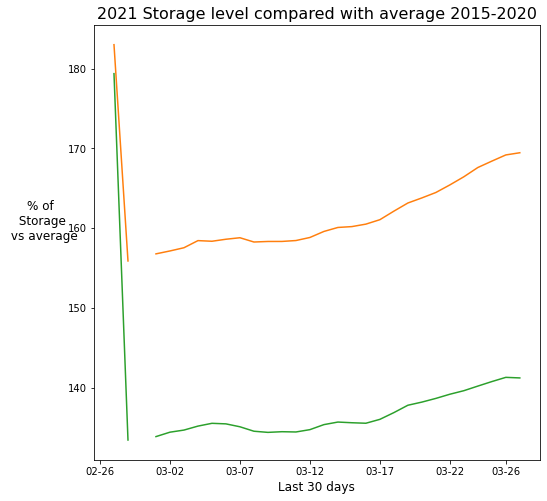

In [109]:
fig, ax = plt.subplots(figsize=(8, 8))

# ax.plot(minvalues_Mm3,label='Minimum')
# ax.plot(maxvalues_Mm3,label='Maximum')
# ax.plot(avgvalues,label='Average')
# ax.plot(values2021_Mm3,label='2021')
ax.plot(Total_last,label='Total')
ax.plot(Gazprom_last,label='Gazprom')


plt.title('2021 Storage level compared with average 2015-2020',fontsize='16')
plt.ylabel('% of \n Storage \n vs average',fontsize=12,rotation=0,labelpad=25)
plt.xlabel('Last 30 days',fontsize=12,rotation=0)
plt.xticks([0,5,10,15,20,25,29])
# plt.ylim((10,90))
# plt.legend()
plt.show()
fig.savefig('figures/Gazprom storage.png',dpi=300,bbox_inches="tight")

# Monthly and weekly data

In [110]:
euplot_monthly = EUdff[EUdff['country']== 'eu'].groupby(pd.Grouper(freq='M')).mean()
euplot_weekly = EUdff[EUdff['country']== 'eu'].groupby(pd.Grouper(freq='W')).mean()
# If we want to convert to Million Cubic meters
converter=0.0103
euplot2 = EUdff[EUdff['country']== 'eu'].groupby(pd.Grouper(freq='M')).mean()/converter
euplot2_weekly = EUdff[EUdff['country']== 'eu'].groupby(pd.Grouper(freq='W')).mean()/converter

 This is in TWh

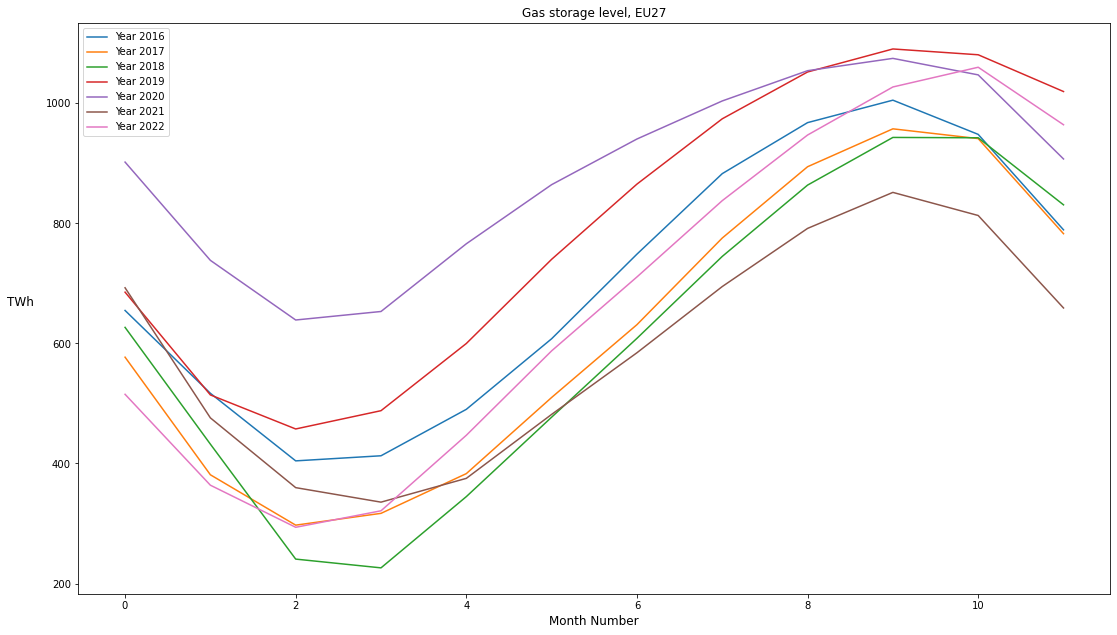

In [111]:
fig, ax = plt.subplots()
fig.set_size_inches(18.5, 10.5)
for yr in ['2016','2017','2018','2019','2020','2021','2022']:
    ax.plot(euplot_monthly.loc[yr].values, label = 'Year {}'.format(yr))
    plt.legend(loc='best')
    plt.title('Gas storage level, EU27')
    plt.ylabel('TWh',fontsize=12,rotation=0,labelpad=25)
    plt.xlabel('Month Number',fontsize=12,rotation=0)

This is in Mm3

In [112]:
euplot2_weekly

,values
dates,
2015-01-04,71993.560680
2015-01-11,69195.400832
2015-01-18,65849.622746
2015-01-25,61423.070735
2015-02-01,56587.077670
...,...
2023-03-05,65697.672677
2023-03-12,62539.733703
2023-03-19,61020.070735


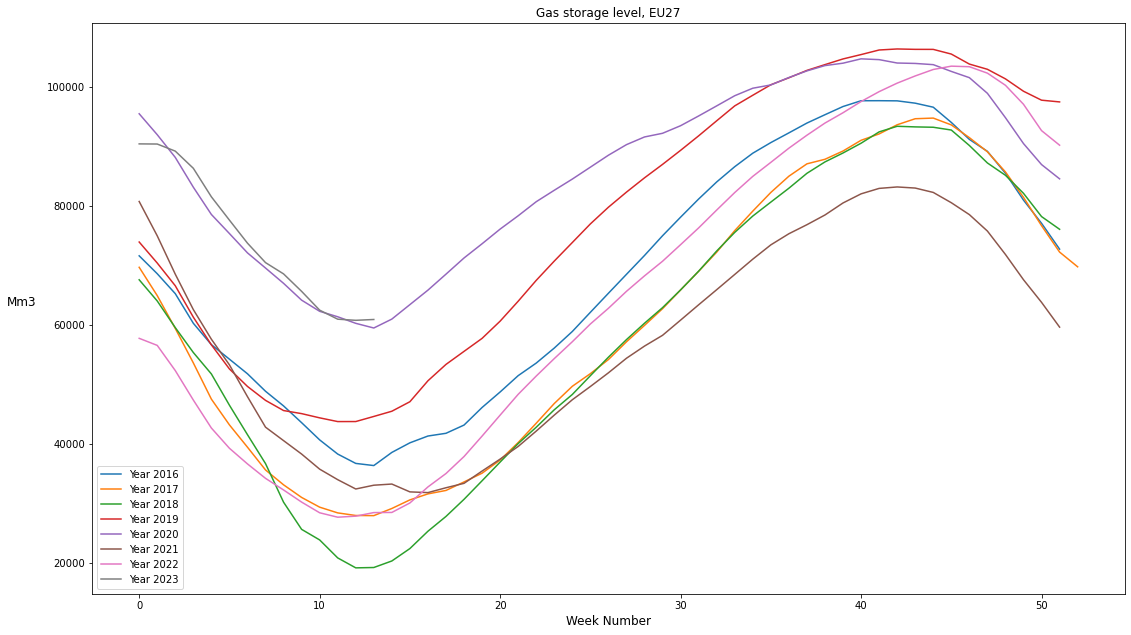

In [114]:
fig, ax = plt.subplots()
fig.set_size_inches(18.5, 10.5)
for yr in ['2016','2017','2018','2019','2020','2021','2022','2023']:
    ax.plot(euplot2_weekly.loc[yr].values, label = 'Year {}'.format(yr))
    plt.legend(loc='best')
    plt.title('Gas storage level, EU27')
    plt.ylabel('Mm3',fontsize=12,rotation=0,labelpad=25)
    plt.xlabel('Week Number',fontsize=12,rotation=0)

In [115]:
EU = df['country'].unique()

In [116]:
#compare by week or month
compare = 'weekly'

C:\Users\GIOVAN~1.SGA\AppData\Local\Temp/ipykernel_29524/96806927.py:3: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series.  To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  country_plot['weekly'] = country_plot.index.week


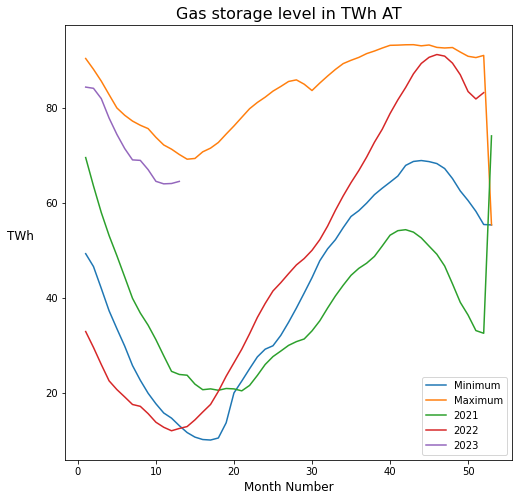

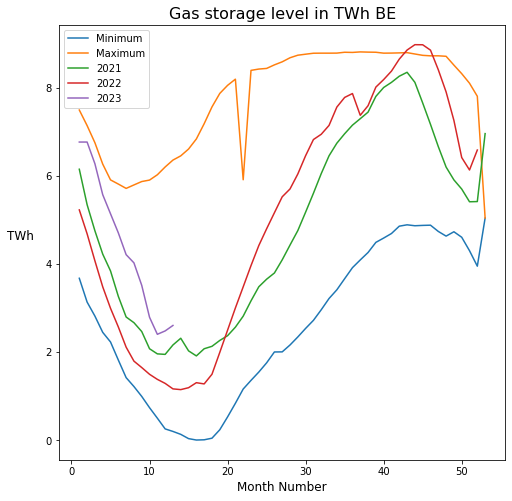

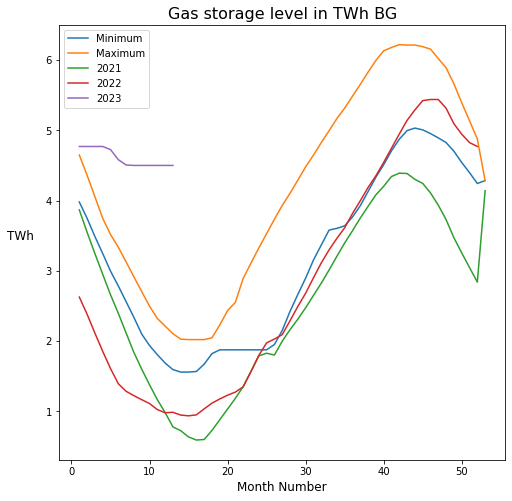

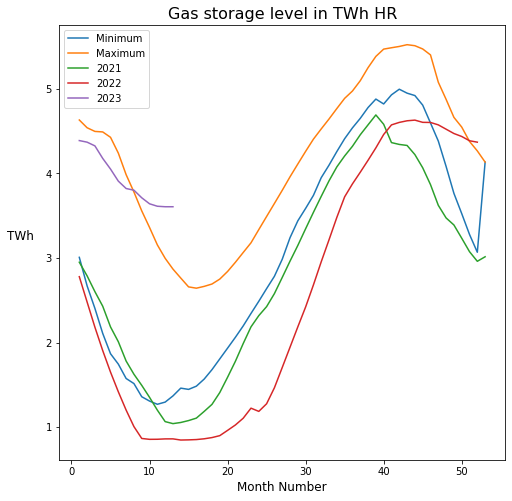

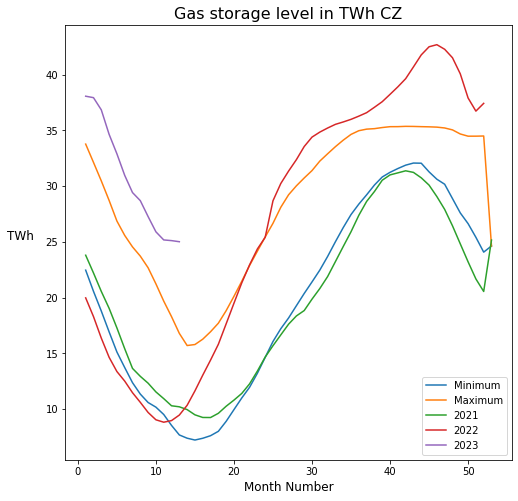

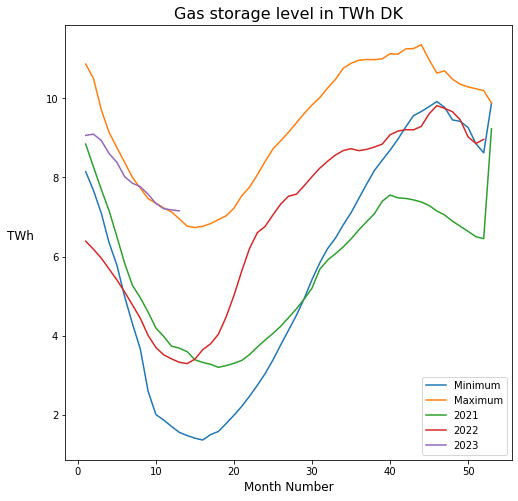

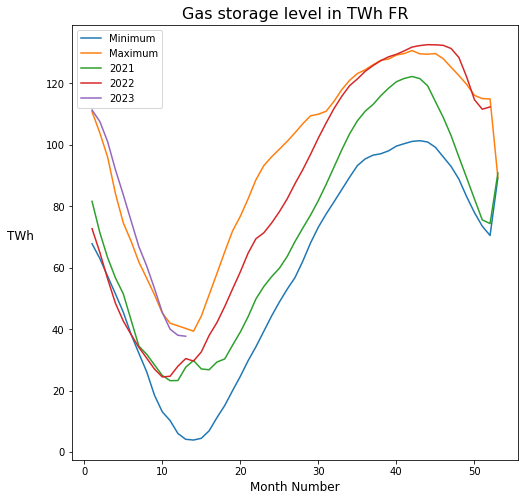

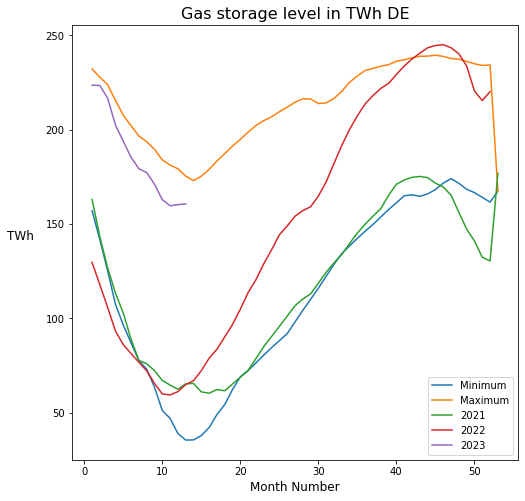

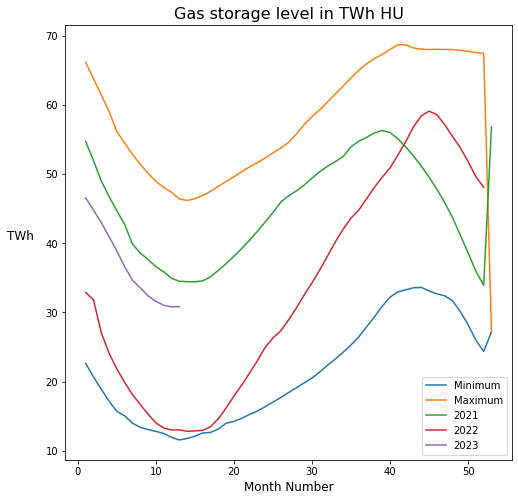

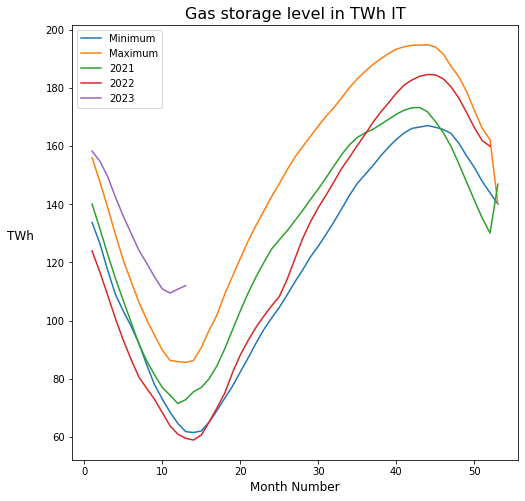

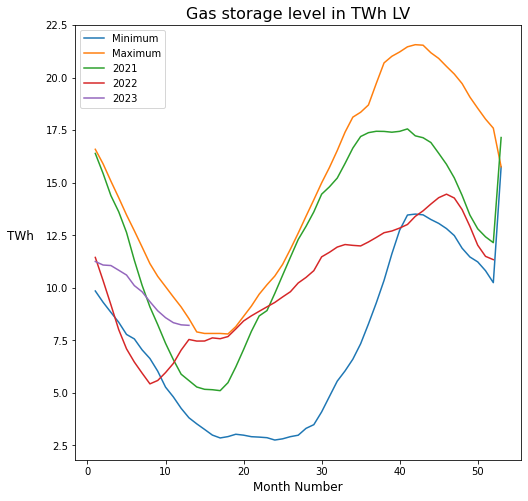

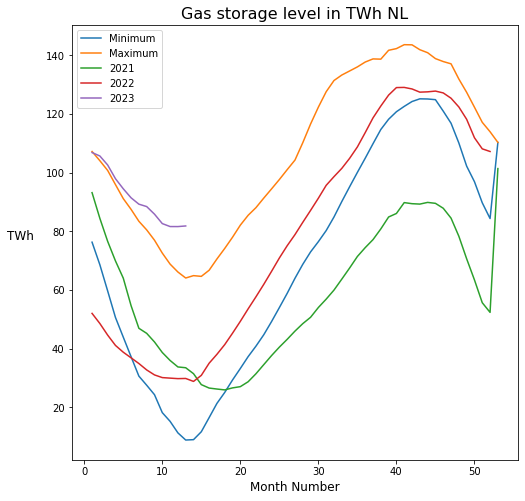

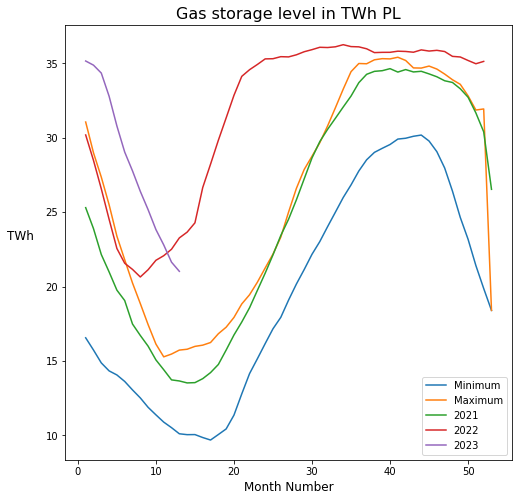

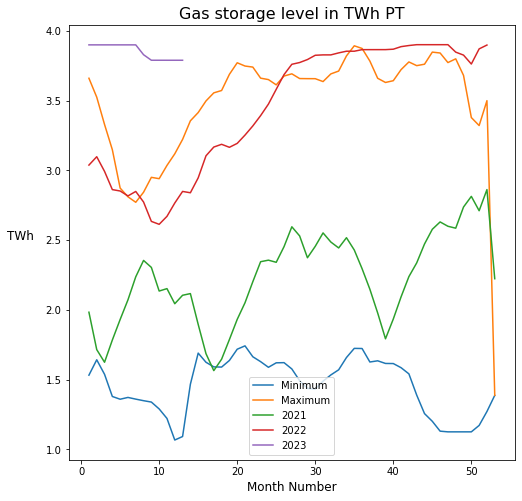

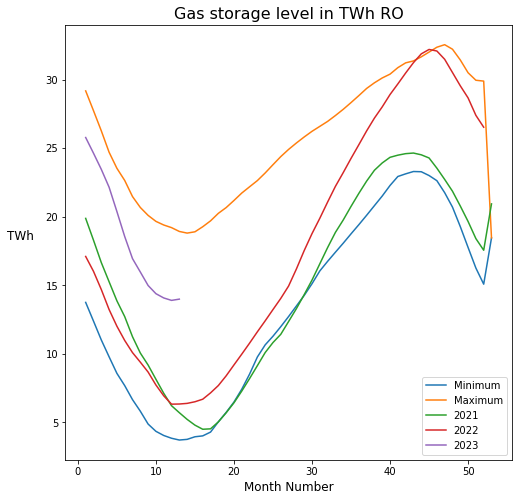

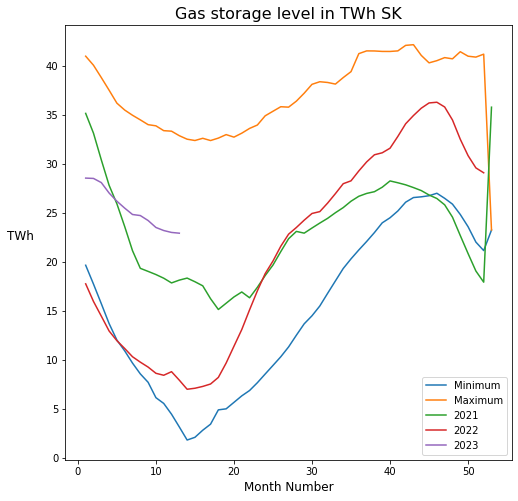

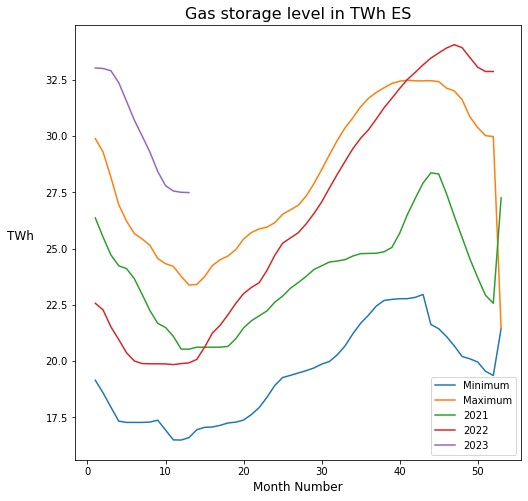

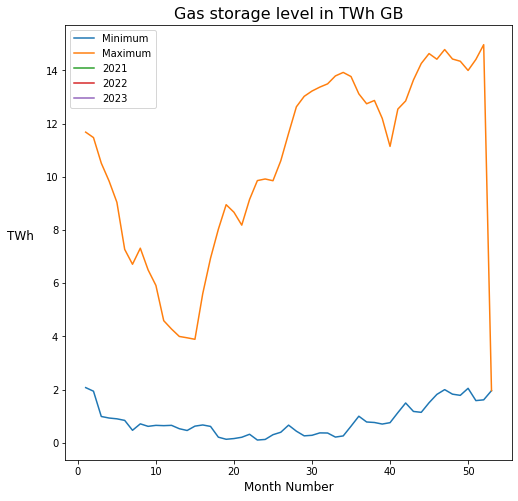

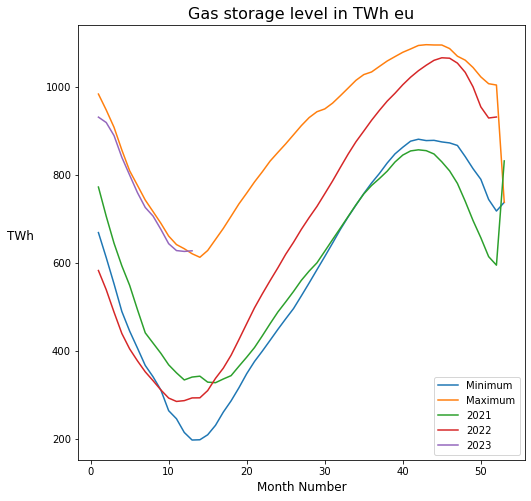

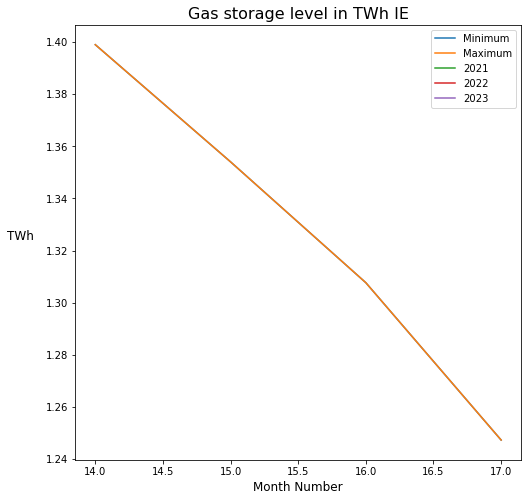

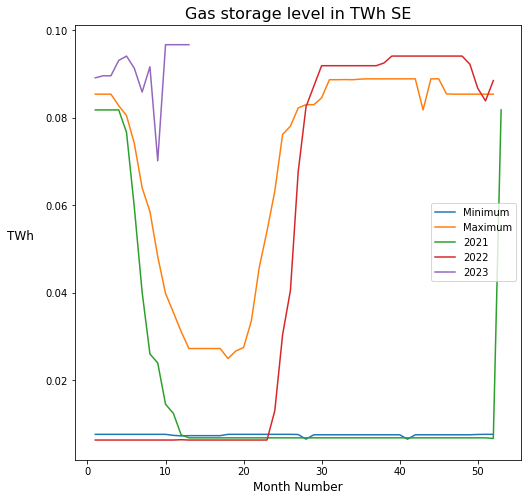

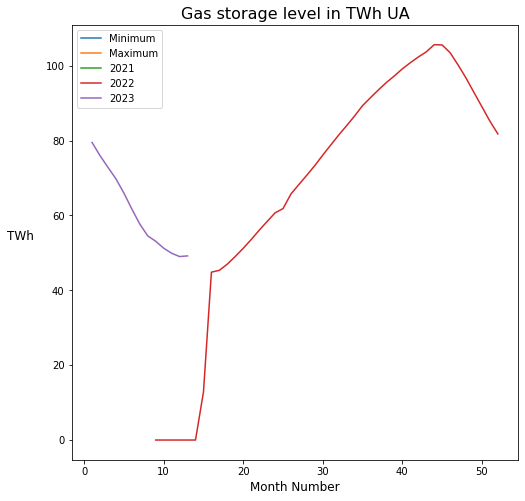

In [118]:
for item in EU:
    country_plot = EUdff[EUdff['country']== '{}'.format(item)].groupby(pd.Grouper(freq='W')).mean()[:]
    country_plot['weekly'] = country_plot.index.week
    minvalues = country_plot['2015-01-01':'2020'].groupby(compare).min()
    maxvalues = country_plot['2015-01-01':'2020'].groupby(compare).max()
    # avgvalues = GazpromPlot['2015-01-05':'2020'].groupby(compare).mean()
    values2021 = country_plot.loc['2021-01-01':'2022-01-02'].groupby(compare).mean()
    values2022 = country_plot.loc['2022-01-03':'2023-01-01'].groupby(compare).mean()
    values2023 = country_plot.loc['2023-01-02':].groupby(compare).mean()
    
    fig, ax = plt.subplots(figsize=(8, 8))

    ax.plot(minvalues,label='Minimum')
    ax.plot(maxvalues,label='Maximum')
    # ax.plot(avgvalues,label='Average')
    ax.plot(values2021,label='2021')
    ax.plot(values2022,label='2022')
    ax.plot(values2023,label='2023')

    plt.title('Gas storage level in TWh {}'.format(item),fontsize='16')
    plt.ylabel('TWh',fontsize=12,rotation=0,labelpad=25)
    plt.xlabel('Month Number',fontsize=12,rotation=0)
    plt.legend()
    plt.show()
    fig.savefig('Storage by country/countries pics/{}/{}.png'.format(compare,item),dpi=300,bbox_inches="tight")

In [90]:
EUdff.groupby(pd.Grouper(freq='W')).mean()

,values
dates,
2015-01-04,78.056170
2015-01-11,75.022378
2015-01-18,71.394854
2015-01-25,66.595539
2015-02-01,61.352308
...,...
2022-11-13,111.912160
2022-11-20,111.718684
2022-11-27,110.435401


### Transform to M3m

In [98]:
converter=0.0103
#compare by week or month
compare = 'weekly'

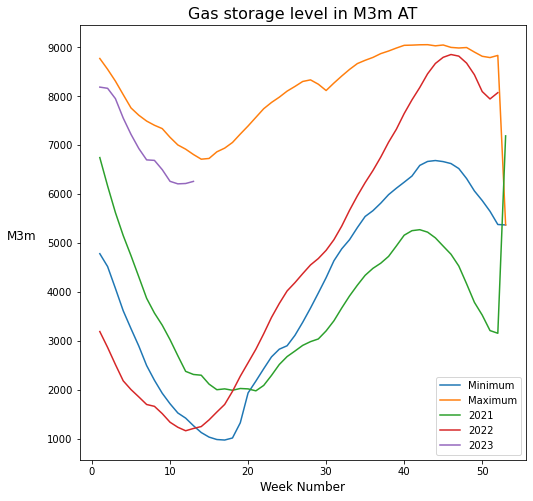

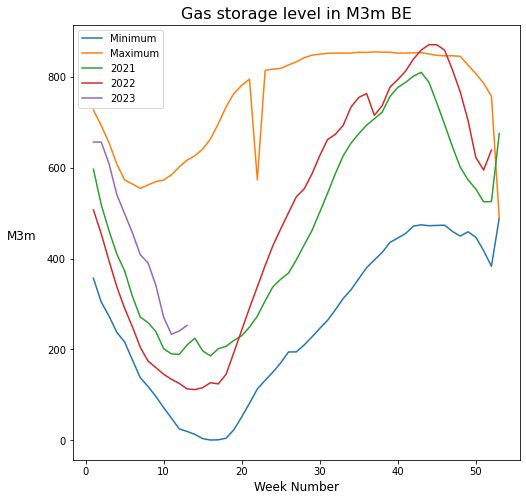

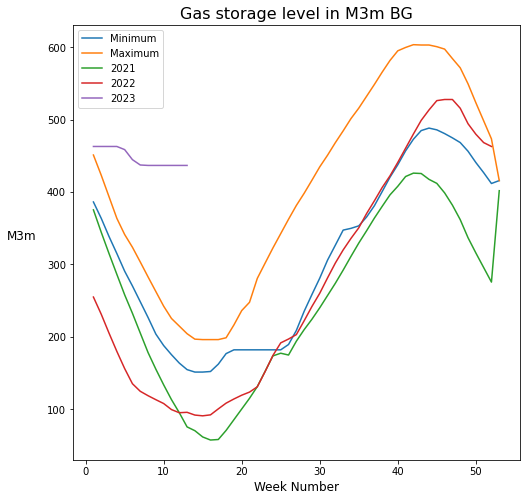

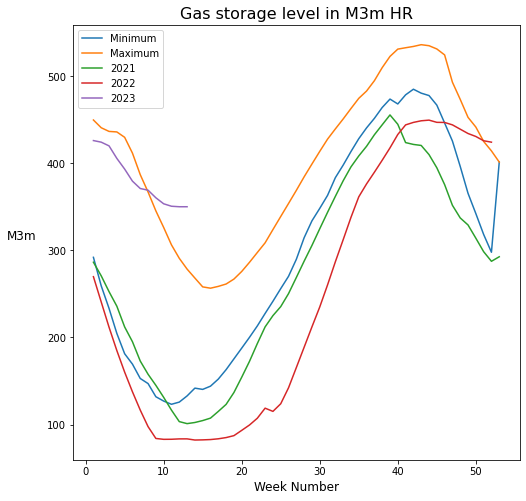

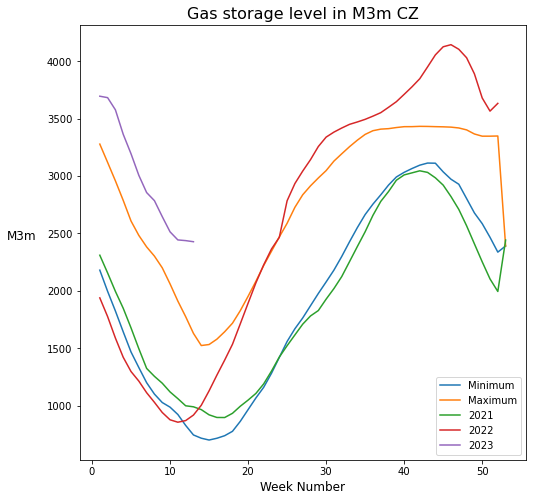

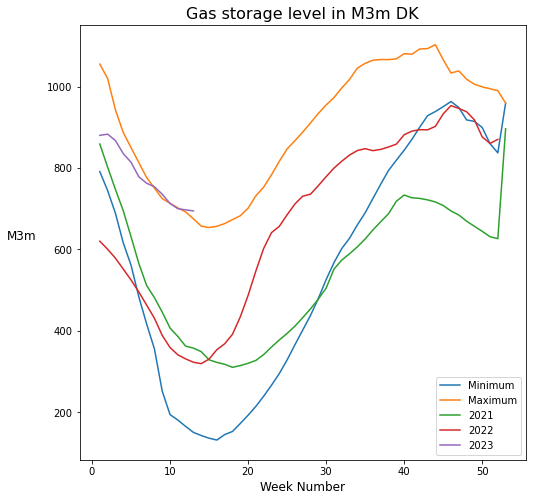

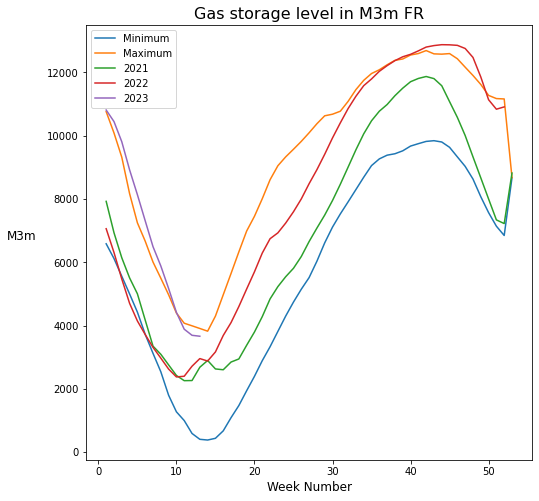

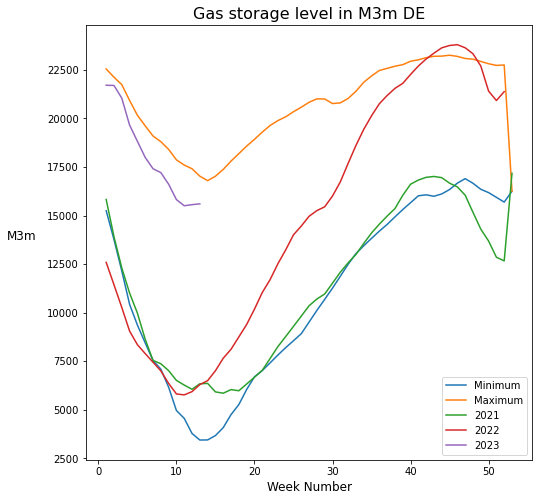

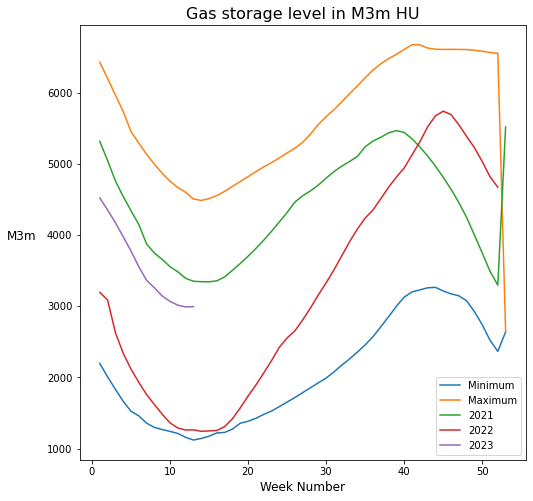

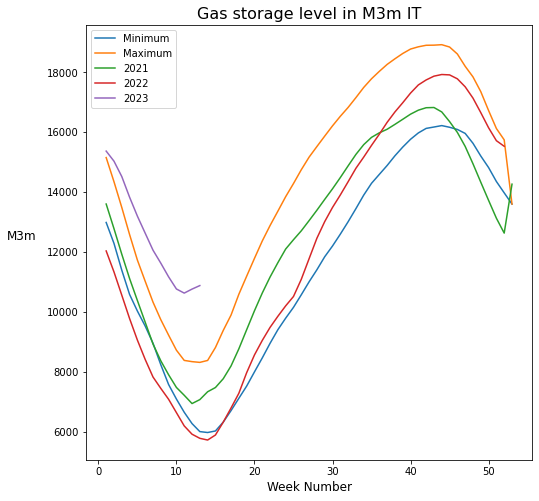

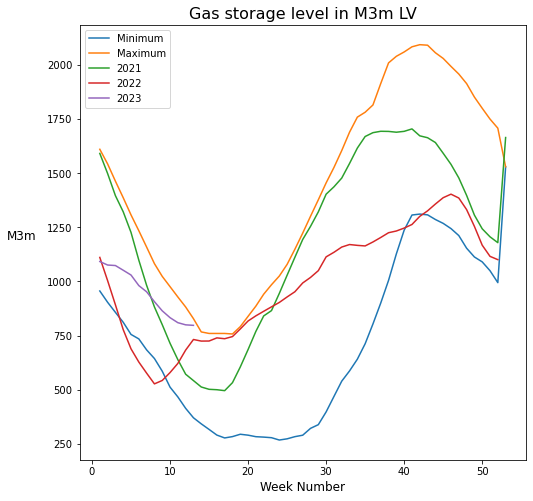

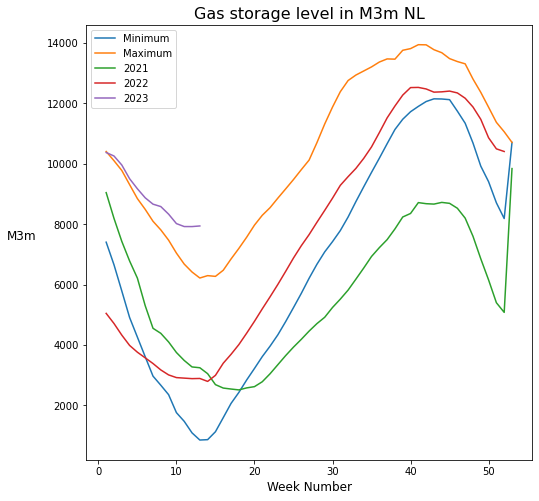

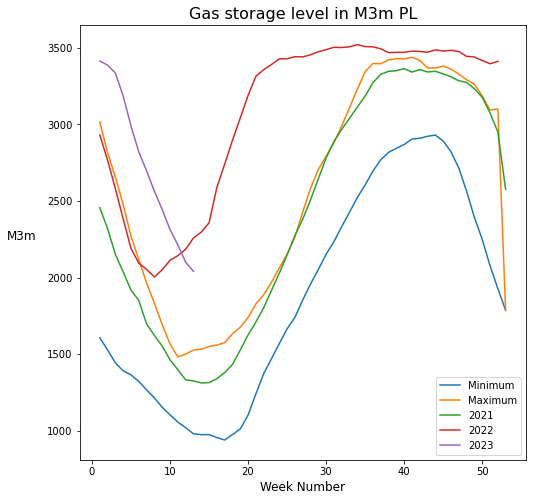

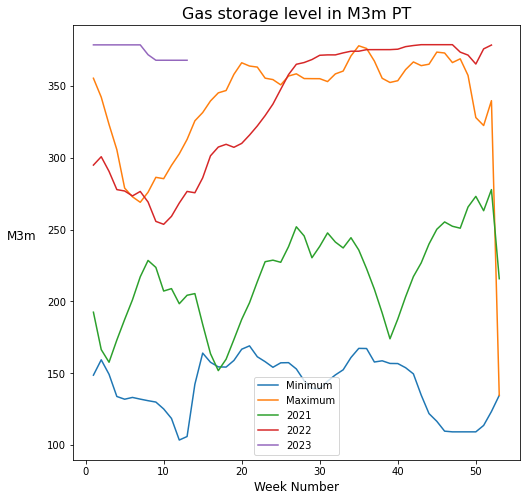

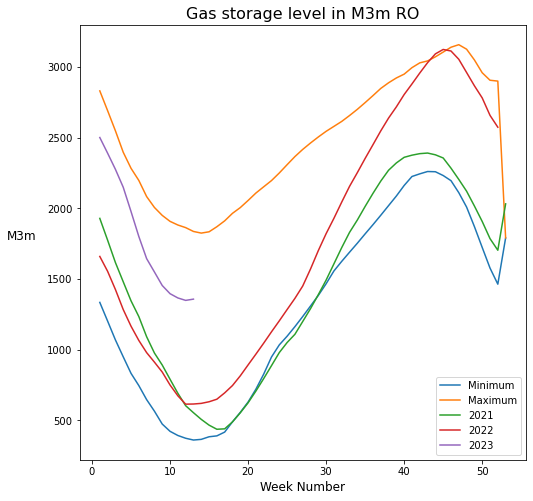

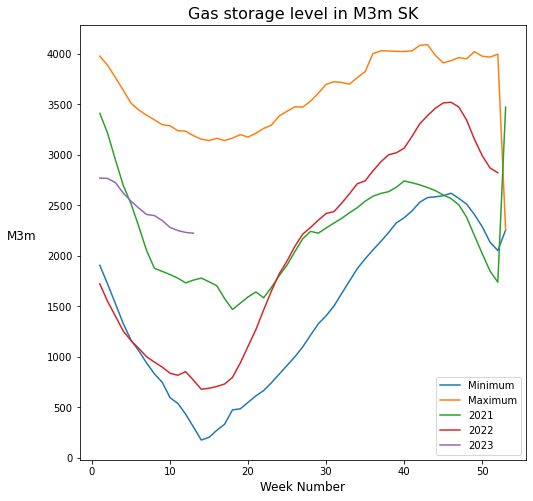

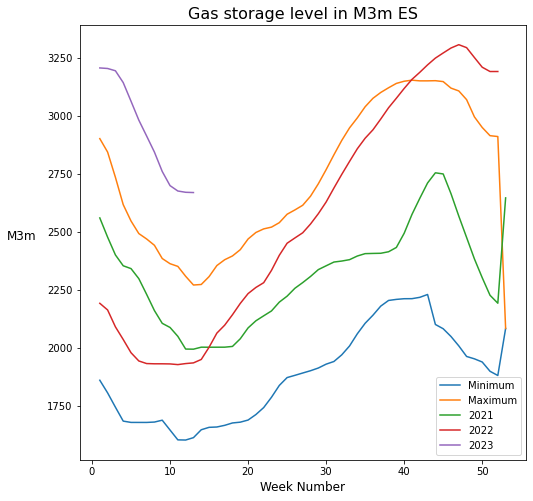

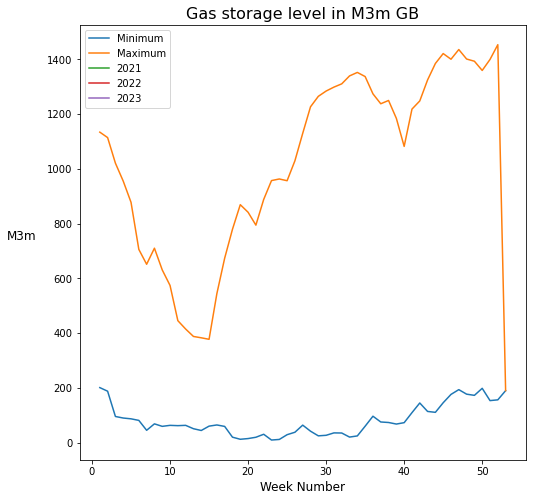

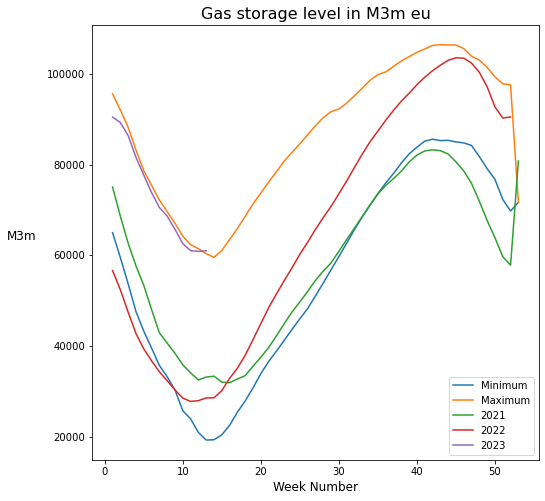

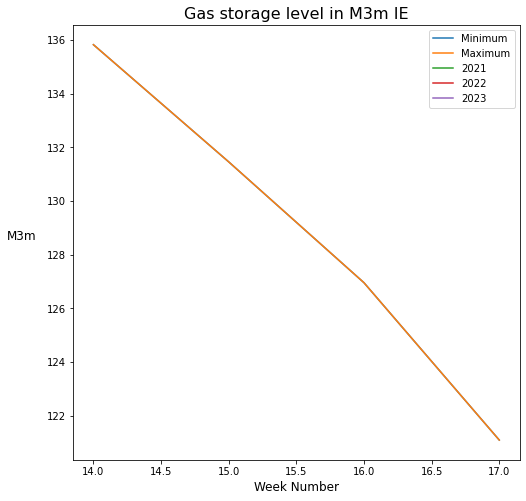

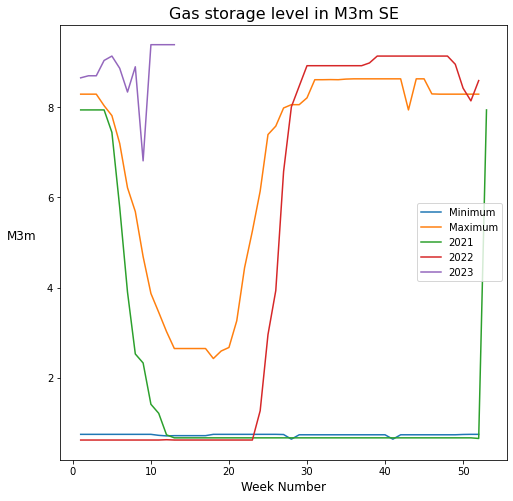

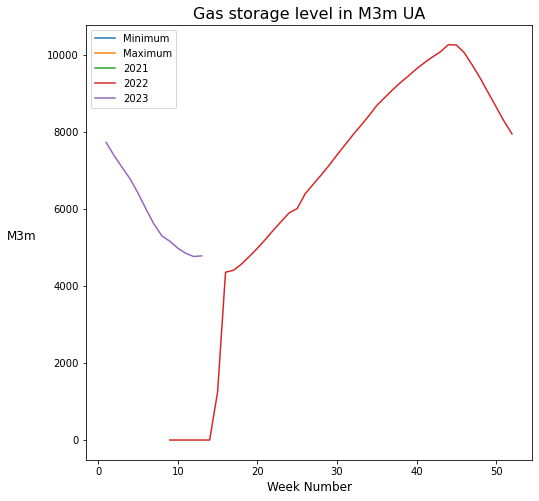

In [119]:
for item in EU:
    country_plot = EUdff[EUdff['country']== '{}'.format(item)].groupby(pd.Grouper(freq='W')).mean()/converter
    country_plot['weekly'] = country_plot.index.isocalendar().week
    minvalues = country_plot['2015-01-01':'2020'].groupby(compare).min()
    maxvalues = country_plot['2015-01-01':'2020'].groupby(compare).max()
    # avgvalues = GazpromPlot['2015-01-05':'2020'].groupby(compare).mean()
    values2021 = country_plot.loc['2021-01-01':'2022-01-02'].groupby(compare).mean()
    values2022 = country_plot.loc['2022-01-03':'2023-01-01'].groupby(compare).mean()
    values2023 = country_plot.loc['2023-01-02':].groupby(compare).mean()
    
    fig, ax = plt.subplots(figsize=(8, 8))

    ax.plot(minvalues,label='Minimum')
    ax.plot(maxvalues,label='Maximum')
    # ax.plot(avgvalues,label='Average')
    ax.plot(values2021,label='2021')
    ax.plot(values2022,label='2022')
    ax.plot(values2023,label='2023')

    plt.title('Gas storage level in M3m {}'.format(item),fontsize='16')
    plt.ylabel('M3m',fontsize=12,rotation=0,labelpad=25)
    plt.xlabel('Week Number',fontsize=12,rotation=0)
    plt.legend()
    plt.show()
    fig.savefig('Storage by country/countries pics/{}/{}.png'.format(compare,item),dpi=300,bbox_inches="tight")
    minvalues.to_csv

### Here save the EU weekly values 2021

In [120]:
Europe= df['country'].unique()

In [121]:
converter=0.0103
#compare by week or month
compare = 'weekly'

In [122]:
df_comparison = EUdff[EUdff['country']=='eu']
df_comparison = df_comparison.groupby(pd.Grouper(freq='W')).mean()
# df_comparison['weekly'] = df_comparison.index.week
df_comparison['weekly'] = df_comparison.index.isocalendar().week
# df_comparison = df_comparison.set_index(pd.DatetimeIndex())

In [123]:
EUdff

,country,values
dates,,
2015-01-01,AT,49.7579
2015-01-02,AT,49.3627
2015-01-03,AT,49.0883
2015-01-04,AT,48.7893
2015-01-05,AT,48.3368
...,...,...
2023-03-23,eu,625.6851
2023-03-24,eu,627.2378
2023-03-25,eu,628.7806


In [124]:
minvalues = df_comparison['2015-01-01':'2020'].groupby('weekly').min()/converter
maxvalues = df_comparison['2015-01-01':'2020'].groupby('weekly').max()/converter
avgvalues = df_comparison['2015-01-01':'2020'].groupby('weekly').mean()/converter
values2021 = df_comparison.loc['2021-01-02':'2022-01-02'].groupby('weekly').mean()/converter
values2022 = df_comparison.loc['2022-01-02':'2023-01-01'].groupby('weekly').mean()/converter
values2023 = df_comparison.loc['2023-01-02':].groupby('weekly').mean()/converter

In [125]:
type(minvalues)

pandas.core.frame.DataFrame

In [99]:
# Create a Pandas Excel writer using XlsxWriter as the engine and save average and 2021 values.
# from datetime import date
# writer = pd.ExcelWriter(r'EU weekly/Weekly Storage EU {}.xlsx'.format(date.today()), engine='xlsxwriter')

# # Write each dataframe to a different worksheet.
# minvalues.round(1).to_excel(writer, sheet_name='Minimum')
# maxvalues.round(1).to_excel(writer, sheet_name='Maximum')
# values2021.round(1).to_excel(writer, sheet_name='2021')
# values2022.round(1).to_excel(writer, sheet_name='2022')
# euplot2_weekly.to_excel(writer, sheet_name = 'dataset')
# writer.save()
# writer.close()

In [100]:
EU_weekly = pd.DataFrame()
EU_weekly['minvalues'] = minvalues.round(1)
EU_weekly['maxvalues'] = maxvalues.round(1)
EU_weekly['2021'] = values2021.round(1)
EU_weekly['2022'] = values2022.round(1)

In [101]:
date.today()

datetime.date(2022, 12, 7)

In [102]:
from datetime import date
EU_weekly.to_excel('EU weekly\Weekly Storage EU {}.xlsx'.format(date.today()))

## For control points

In [108]:
df_8b

,dates,values,% full,status,Max Storage,country
0,2022-11-27,90.8008,95.03,C,95.5464,AT
1,2022-11-26,90.7682,95.00,C,95.5464,AT
2,2022-11-25,90.6618,94.89,C,95.5464,AT
3,2022-11-24,90.7556,94.99,C,95.5464,AT
4,2022-11-23,90.8361,95.07,C,95.5464,AT
...,...,...,...,...,...,...
3445,2022-07-05,668.2794,60.27,C,1108.7551,eu
3446,2022-07-04,664.3162,59.92,C,1108.7551,eu
3447,2022-07-03,660.2405,59.55,C,1108.7309,eu
3448,2022-07-02,655.1873,59.09,C,1108.7308,eu


In [109]:
df_8b = pd.read_csv('Storage by country\historic data (10.05.2022)\Storage_2022_2.csv',index_col=0)

In [110]:
from datetime import date
today = date.today()
last = today - timedelta(days=2)

In [111]:
str(last)

'2022-11-27'

In [112]:
latest_df = df_8b[df_8b['dates']== str(last)]

In [113]:
import os 
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - 2021-11 European natural gas imports\\Data\\Storage'

In [114]:
df_CP = pd.read_excel('Storage by country\EC control points.xlsx')

In [115]:
df_CP.columns

Index(['country', 'August 1st control point level',
       'September 1st control point level', 'October 1st control point level',
       'November 1st target point level'],
      dtype='object')

In [116]:
CPL = latest_df.merge(df_CP,on='country')

In [117]:
CPL.columns

Index(['dates', 'values', '% full', 'status', 'Max Storage', 'country',
       'August 1st control point level', 'September 1st control point level',
       'October 1st control point level', 'November 1st target point level'],
      dtype='object')

In [118]:
CPL['80% target (11.2022)'] = round(CPL['Max Storage']*CPL['November 1st target point level'],1)
CPL['10.2022 TWh'] = round(CPL['Max Storage']*CPL.iloc[:,8],1)
CPL['09.2022 TWh'] = round(CPL['Max Storage']*CPL['September 1st control point level'],1)
CPL['08.2022 TWh'] = round(CPL['Max Storage']*CPL['August 1st control point level'],1)

In [119]:
riga = 'dimmi chi sei // e come andare \n a capo'
print(riga)

dimmi chi sei // e come andare 
 a capo


In [120]:
CPL

,dates,values,% full,status,Max Storage,country,August 1st control point level,September 1st control point level,October 1st control point level,November 1st target point level,80% target (11.2022),10.2022 TWh,09.2022 TWh,08.2022 TWh
0,2022-11-27,90.8008,95.03,C,95.5464,AT,0.57,0.65,0.72,0.8,76.4,68.8,62.1,54.5
1,2022-11-27,8.2925,100.00,C,7.6100,BE,0.75,0.77,0.78,0.8,6.1,5.9,5.9,5.7
2,2022-11-27,5.4374,93.71,C,5.8025,BG,0.59,0.66,0.73,0.8,4.6,4.2,3.8,3.4
3,2022-11-27,4.5642,95.64,C,4.7725,HR,0.58,0.65,0.73,0.8,3.8,3.5,3.1,2.8
4,2022-11-27,42.1507,96.23,C,43.7999,CZ,0.62,0.68,0.74,0.8,35.0,32.4,29.8,27.2
5,2022-11-27,9.7353,97.94,C,9.9404,DK,0.68,0.72,0.76,0.8,8.0,7.6,7.2,6.8
6,2022-11-27,131.0657,98.10,C,133.6026,FR,0.60,0.67,0.73,0.8,106.9,97.5,89.5,80.2
7,2022-11-27,243.3845,98.88,C,246.1328,DE,0.62,0.68,0.74,0.8,196.9,182.1,167.4,152.6
8,2022-11-27,56.3276,83.20,C,67.7027,HU,0.60,0.67,0.73,0.8,54.2,49.4,45.4,40.6
9,2022-11-27,179.2605,92.67,C,193.4434,IT,0.66,0.71,0.75,0.8,154.8,145.1,137.3,127.7


In [121]:
CPL.to_excel('Control Point Levels by country.xlsx')

## Data for Storage by country for Hector

In [122]:
df_comparison.iloc[-5:]

,values,weekly
dates,,
2022-10-30,1049.565171,43
2022-11-06,1060.580271,44
2022-11-13,1066.344643,45
2022-11-20,1065.444629,46
2022-11-27,1054.269486,47


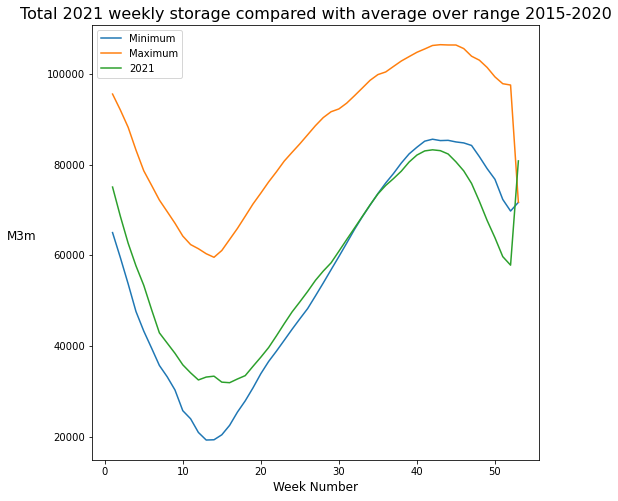

In [123]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(minvalues,label='Minimum')
ax.plot(maxvalues,label='Maximum')
# ax.plot(avgvalues,label='Average')
ax.plot(values2021,label='2021')

plt.title('Total 2021 weekly storage compared with average over range 2015-2020',fontsize='16')
plt.ylabel('M3m',fontsize=12,rotation=0,labelpad=25)
plt.xlabel('Week Number',fontsize=12,rotation=0)
plt.legend()
plt.show()
fig.savefig('figures/Total_storage (monthly).png',dpi=300,bbox_inches="tight")

## Storage capacity by country

In [124]:
# Set the most recent date for which we have observations
last_date = str(today- timedelta(2))

In [125]:
df_capacity = df.groupby(['country','dates'])['Max Storage'].mean().reset_index()
df_capacity = df_capacity.set_index(pd.DatetimeIndex(df_capacity['dates']))
converter=0.0103
df_capacity['M3m'] = df_capacity['Max Storage']/converter
euplot_capacity = df_capacity[df_capacity['dates']== last_date]

In [126]:
from datetime import date
euplot_capacity.to_csv('Storage by country/weekly/Storage capacity {}.csv'.format(date.today()))

In [127]:
df_capacity[df_capacity['dates']== '2022-09-18']

,country,dates,Max Storage,M3m
dates,,,,
2022-09-18,AT,2022-09-18,95.5473,9276.436893
2022-09-18,BE,2022-09-18,8.7010,844.757282
2022-09-18,BG,2022-09-18,5.8025,563.349515
2022-09-18,CZ,2022-09-18,43.7739,4249.893204
2022-09-18,DE,2022-09-18,244.5831,23745.932039
2022-09-18,DK,2022-09-18,9.2300,896.116505
2022-09-18,ES,2022-09-18,35.2503,3422.359223
2022-09-18,FR,2022-09-18,132.6052,12874.291262
2022-09-18,HR,2022-09-18,4.7725,463.349515


In [128]:
converter=0.0103
#compare by week or month
compare = 'weekly'
data = pd.DataFrame()
data['week'] = list(range(0,54,1))

for country in twodigit:

    country_plot = EUdff[EUdff['country']== '{}'.format(country)].groupby(pd.Grouper(freq='W')).mean()/converter
    country_plot['weekly'] = country_plot.index.isocalendar().week

    minvalues = country_plot['2015-01-05':'2020'].groupby(compare).min()
    maxvalues = country_plot['2015-01-05':'2020'].groupby(compare).max()
#     avgvalues = country_plot['2015-01-05':'2020'].groupby(compare).mean()
    values2021 = country_plot.loc['2020-12-28':].groupby(compare).max()
    
    data['{}_min'.format(country)] = minvalues
    data['{}_max'.format(country)] = maxvalues
#     data['{}_avg'.format(country)] = avgvalues
    data['{}_2021'.format(country)] = values2021    

data = data.round(1)
from datetime import date
today = date.today()
data.to_excel('Storage by country/weekly/country_storage_data {}.xlsx'.format(today))

# Not used (fill %) and attempts

### This work but days are calendar dates (e.g. day 1 is the first of the month)

In [136]:
# Very dumb way around it
values_30_days = EUdff_30.iloc[-31:]
values_30_days['daily'] = range(1,32)  # I tried to be smart with groupby() by I didn't manage to
values_30_days = values_30_days.set_index(values_30_days['daily']) 
del values_30_days['daily']

C:\Users\GIOVAN~1.SGA\AppData\Local\Temp/ipykernel_20020/1117539231.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  values_30_days['daily'] = range(1,32)  # I tried to be smart with groupby() by I didn't manage to


In [163]:
# Lionel
# EUdff_30 = EUdff_30.reset_index().merge(avgvalues.reset_index(), on='daily')
# EUdff_30 = EUdff_30.sort_values('dates').set_index('dates')
# EUdff_30['ratio'] = EUdff_30['values_x']/EUdff_30['values_y']

In [ ]:
# country = 'eu'

In [12]:
# df_country = df[df['country']=='{}'.format(country)]
# df_country = df_country['% full']

In [14]:
# df_country = df_country.to_frame()
# df_country.drop_duplicates()
# df_country.head()

,% full
dates,
2021-10-26,77.06
2021-10-25,77.15
2021-10-24,77.18
2021-10-23,77.16
2021-10-22,77.19


In [42]:
df_country.loc['2020'].count()

% full    366
dtype: int64

In [47]:
df_country.loc['2018'].min()

% full    17.76
dtype: float64

In [48]:
df_country.loc['2018'].idxmin()

% full   2018-03-30
dtype: datetime64[ns]

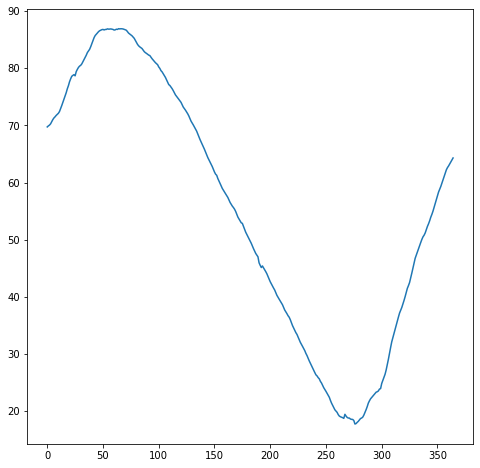

In [43]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(df_country.loc['2018'].values)
plt.show()

In [69]:
minvalues = df_comparison['2015-01-05':'2020'].groupby('weekly').min()
maxvalues = df_comparison['2015-01-05':'2020'].groupby('weekly').max()
avgvalues = df_comparison['2015-01-05':'2020'].groupby('weekly').mean()
values2021 = df_comparison.loc['2021-01-05':].groupby('weekly').mean()

In [70]:
avgvalues

,values
weekly,
1,81.311063
2,77.298615
3,72.435172
4,67.197929
5,62.678159
6,58.273091
7,54.026313
8,50.457405
9,46.869859


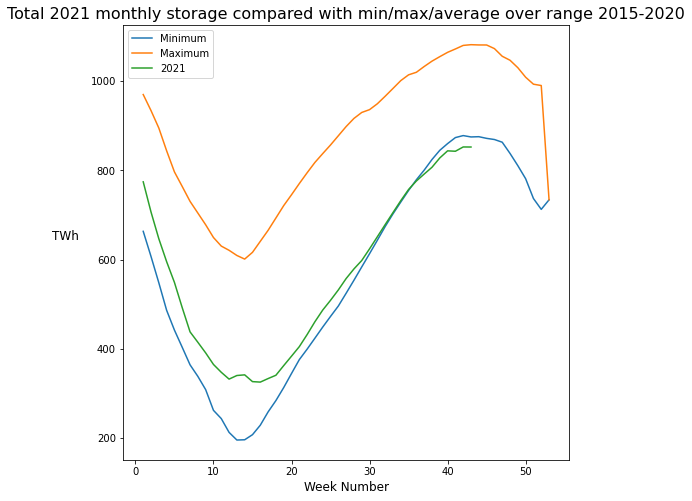

In [42]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(minvalues,label='Minimum')
ax.plot(maxvalues,label='Maximum')
# ax.plot(avgvalues,label='Average')
ax.plot(values2021,label='2021')

plt.title('Total 2021 monthly storage compared with min/max/average over range 2015-2020',fontsize='16')
plt.ylabel('TWh',fontsize=12,rotation=0,labelpad=25)
plt.xlabel('Week Number',fontsize=12,rotation=0)
plt.legend()
plt.show()
fig.savefig('figures/Total_storage (monthly).png',dpi=300,bbox_inches="tight")

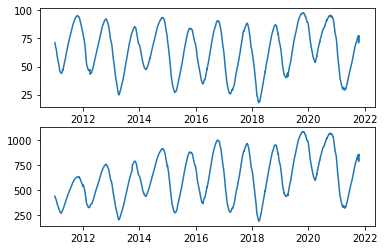

In [15]:
date_form = DateFormatter("%Y%M")

fig, (ax0,ax1) = plt.subplots(2,1)

y0=df_country['% full']
y1=df_country['values']
x = df_country.index.values

ax0.plot(x, y0)
ax1.plot(x, y1)
                           
# plt.plot(df['values'])
# ax.xaxis.set_major_formatter(date_form)
#plt.plot(df_country.groupby(pd.Grouper(freq='M')).values,label='values')


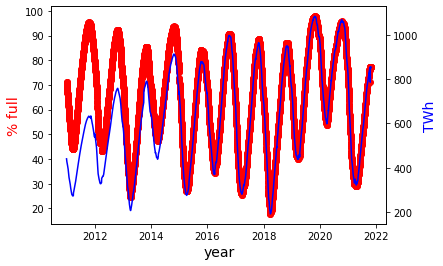

In [17]:
# create figure and axis objects with subplots()
fig,ax = plt.subplots()

x = df_country.index.values
# make a plot
ax.plot(x, df_country['% full'], color="red", marker="o")
# set x-axis label
ax.set_xlabel("year",fontsize=14)
# set y-axis label
ax.set_ylabel("% full",color="red",fontsize=14)
# twin object for two different y-axis on the sample plot
ax2=ax.twinx()
# make a plot with different y-axis using second axis object
ax2.plot(x, df_country['values'],color="blue")
ax2.set_ylabel("TWh",color="blue",fontsize=14)
plt.show()
# save the plot as a file
fig.savefig('two_different_y_axis_for_single_python_plot_with_twinx.jpg',
            format='jpeg',
            dpi=100,
            bbox_inches='tight')

<AxesSubplot:xlabel='dates'>

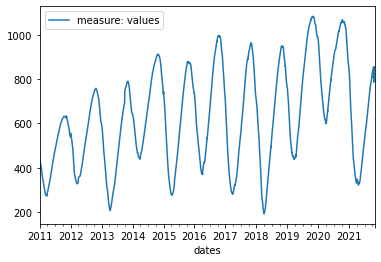

In [81]:
# Either ''% full' or 'values'
measure = 'values'

df_country = df[df['country']=='eu']
df_country = df_country.set_index(pd.DatetimeIndex(df_country['dates']))
date_form = DateFormatter("%Y%M")

df_country.plot(y='{}'.format(measure),use_index=True, label='measure: {}'.format(measure))




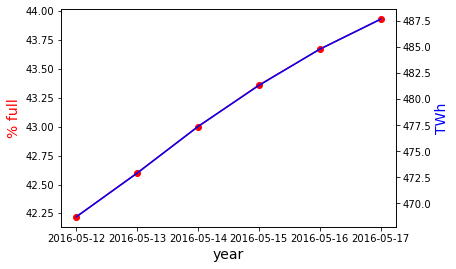

In [22]:
startdate = 2018-10-21
enddate = 2020-12-15

# create figure and axis objects with subplots()
fig,ax = plt.subplots()

x = df_country.index.values[startdate:enddate]
# make a plot
ax.plot(x, df_country['% full'][startdate:enddate], color="red", marker="o")
# set x-axis label
ax.set_xlabel("year",fontsize=14)
# set y-axis label
ax.set_ylabel("% full",color="red",fontsize=14)
# twin object for two different y-axis on the sample plot
ax2=ax.twinx()
# make a plot with different y-axis using second axis object
ax2.plot(x, df_country['values'][startdate:enddate],color="blue")
ax2.set_ylabel("TWh",color="blue",fontsize=14)
plt.show()
# save the plot as a file
fig.savefig('two_different_y_axis_for_single_python_plot_with_twinx.jpg',
            format='jpeg',
            dpi=100,
            bbox_inches='tight')

In [ ]:
# Gazprom Germany 
Etzel = ['UGS Oude Statenzijl ETZEL Crystal', 'UGS Etzel EGL (Equinor Storage Deutschland)',
         'UGS Etzel ESE (Gas Union Storage)', 'UGS Etzel ESE (OMV)',
         'UGS Etzel Erdgas Lager EGL', 'UGS Etzel ESE (Uniper Energy Storage)', 'UGS Etzel ESE (VGS)']
Jemgum   = ['UGS Jemgum H (astora)', 'VSP NORD (Rehden, Jemgum)', 'UGS Jemgum H (EWE)', 'UGS Jemgum H (VGS)']
Katharina = 'UGS Katharina'
Rehden = 'UGS Rehden'
# Gazprom Austria
Haidach = ['UGS Haidach (astora)', 'UGS Haidach (GSA)']
# Gazprom CZ
Damborice ='UGS Dambořice'